
=== Top-level categories, total count, and number of low-level categories ===
Interaction with Other Road Users: 564   (unique low-level categories: 13)
{'Light', 'Moving forward:Normally', 'Cut in', 'Park', 'Moving forward:Slowly', 'Moving forward:Fast', 'Decelerating', 'Stop', 'Accelerating', 'Heavy', 'Crossing', 'Pedestrian Crossing', 'Changing lane'}
Ego car driving intention: 556   (unique low-level categories: 10)
{'Passing', 'Park', 'Driving forward', 'Enter another road', 'Merging', 'Decelerating', 'Stop', 'Accelerating', 'Turning', 'Changing lane'}
Traffic Conditions: 534   (unique low-level categories: 3)
{'Green light', 'Red light', 'Stop sign'}
Road Condition: 316   (unique low-level categories: 3)
{'Speed bump', 'Exit', 'Clear Road'}
Unclassified: 303   (unique low-level categories: 1)
{'Unclassified'}
Environment: 14   (unique low-level categories: 3)
{'Rain', 'Snow', 'Nighttime'}


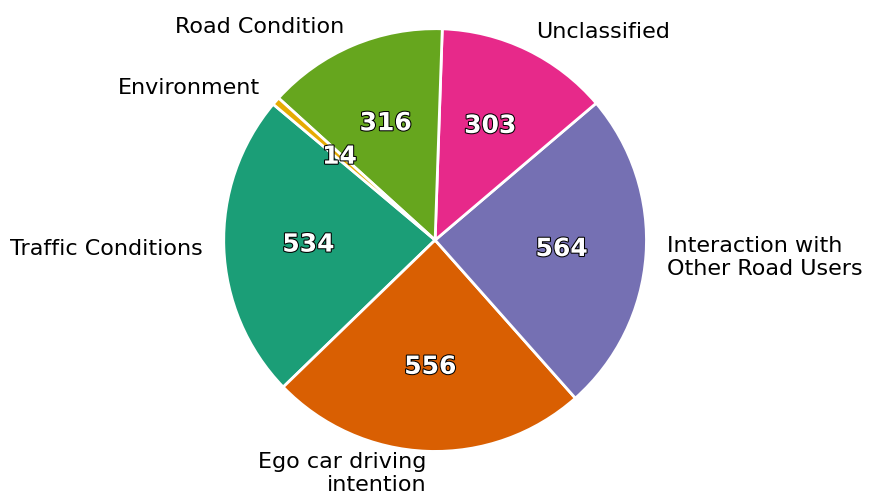

LaTeX table written to: taxonomy_table_merged.tex


In [ ]:
import pandas as pd
from collections import defaultdict

INPUT_CSV = "../annotations/bddx_test_with_justification_category.csv" 


def nested_dict():
    return defaultdict(lambda: defaultdict(lambda: defaultdict(int)))


def load_atomic_labels_from_csv(path, column="Category"):
    df = pd.read_csv(path)
    labels = []

    for raw in df[column].astype(str).fillna(""):
        raw = raw.strip()
        if not raw:
            continue

        # Split multi-label rows: A & B & C
        parts = raw.split("&")

        for p in parts:
            lbl = p.strip().strip('"')
            if lbl:
                labels.append(lbl)

    return labels


def split_levels(label):
    parts = [p.strip() for p in label.split(":")]

    top = parts[0] if len(parts) >= 1 else ""
    mid = parts[1] if len(parts) >= 2 else ""

    if len(parts) <= 2:
        bottom = parts[-1] if parts else ""
    elif len(parts) == 3:
        bottom = parts[-1]
    else:
        bottom = ":".join(parts[2:])

    return top, mid, bottom


def latex_escape(s):
    """Escape LaTeX special characters."""
    return (
        s.replace("&", "\\&")
         .replace("%", "\\%")
         .replace("_", "\\_")
         .replace("#", "\\#")
         .replace("{", "\\{")
         .replace("}", "\\}")
    )

def export_latex_table_merged(hierarchy, output_file="taxonomy_table_merged.tex"):

    with open(output_file, "w", encoding="utf-8") as f:
        f.write(r"% Requires: \usepackage{booktabs}, \usepackage{multirow}" "\n")
        f.write(r"\begin{table*}[ht]" "\n")
        f.write(r"\centering" "\n")
        f.write(r"\begin{tabular}{l l l r}" "\n")
        f.write(r"\toprule" "\n")
        f.write(r"Top level & Mid level & Bottom level & Count \\" "\n")
        f.write(r"\midrule" "\n")

        for top in sorted(hierarchy.keys()):
            top_esc = latex_escape(top)
            mid_keys = sorted(hierarchy[top].keys())
            n_top_rows = sum(len(hierarchy[top][mid]) for mid in mid_keys)

            top_first_row = True

            for mid in mid_keys:
                mid_esc = latex_escape(mid)
                bottom_items = sorted(hierarchy[top][mid].items())
                n_mid_rows = len(bottom_items)

                mid_first_row = True

                for bottom, count in bottom_items:
                    bottom_esc = latex_escape(bottom)

                    # Construct row using raw strings + f-strings
                    row = ""

                    if top_first_row:
                        row += rf"\multirow{{{n_top_rows}}}{{*}}{{{top_esc}}} & "
                        top_first_row = False
                    else:
                        row += " & "

                    if mid_first_row:
                        row += rf"\multirow{{{n_mid_rows}}}{{*}}{{{mid_esc}}} & "
                        mid_first_row = False
                    else:
                        row += " & "

                    row += rf"{bottom_esc} & {count} \\" "\n"
                    f.write(row)

                # <<< MID-LEVEL RULE >>> 
                if not mid == mid_keys[-1]:
                    f.write(r"\cmidrule(lr){2-4}" "\n")

            # <<< TOP-LEVEL RULE >>>
            f.write(r"\midrule" "\n")

        f.write(r"\bottomrule" "\n")
        f.write(r"\end{tabular}" "\n")
        f.write(r"\caption{Scenario taxonomy hierarchy with merged cells and grouped rules. The last column shows the number of instances in the annotated BDD-X test set.}" "\n")
        f.write(r"\end{table*}" "\n")

    print(f"LaTeX table written to: {output_file}")


def export_latex_table(hierarchy, output_file="taxonomy_table.tex"):
    rows = []

    for top in sorted(hierarchy.keys()):
        for mid in sorted(hierarchy[top].keys()):
            for bottom in sorted(hierarchy[top][mid].keys()):
                count = hierarchy[top][mid][bottom]
                rows.append((
                    latex_escape(top),
                    latex_escape(mid),
                    latex_escape(bottom),
                    count
                ))

    with open(output_file, "w", encoding="utf-8") as f:
        f.write("\\begin{table}[ht]\n")
        f.write("\\centering\n")
        f.write("\\scriptsize\n")
        f.write("\\begin{tabular}{l l l r}\n")
        f.write("\\toprule\n")
        f.write("Top level & Mid level & Bottom level & Count \\\\\n")
        f.write("\\midrule\n")

        for top, mid, bottom, count in rows:
            f.write(f"{top} & {mid} & {bottom} & {count} \\\\\n")

        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")
        f.write("\\caption{Scenario taxonomy hierarchy with counts.}\n")
        f.write("\\end{table}\n")

    print(f"LaTeX table written to {output_file}")



def main():
    # Load labels from CSV instead of TXT
    labels = load_atomic_labels_from_csv(INPUT_CSV, column="Category")

    hierarchy = nested_dict()
    top_counts = defaultdict(int)
    mid_counts = defaultdict(int)
    bottom_counts = defaultdict(int)

    for label in labels:
        top, mid, bottom = split_levels(label)

        hierarchy[top][mid][bottom] += 1

        top_counts[top] += 1
        mid_counts[mid] += 1
        bottom_counts[bottom] += 1

    print("\n=== Top-level categories, total count, and number of low-level categories ===")

    for top, count in sorted(top_counts.items(), key=lambda x: -x[1]):

        # Count unique bottom-level categories under this top-level
        bottom_set = set()
        for mid in hierarchy[top]:
            for bottom in hierarchy[top][mid]:
                bottom_set.add(bottom)

        num_bottom = len(bottom_set)

        print(f"{top}: {count}   (unique low-level categories: {num_bottom})")
        print(bottom_set)

    # ---------- PIE CHART ----------
    import matplotlib.pyplot as plt
    from textwrap import fill

    labels = list(top_counts.keys())
    sizes = list(top_counts.values())
    total = sum(sizes)

    def count_label(pct):
        count = int(round(pct * total / 100.0))
        return f"{count}"
    
    wrapped_labels = [fill(l, width=20) for l in labels]

    plt.figure(figsize=(6, 6))
    wedges, texts, autotexts = plt.pie(
        sizes,
        labels=wrapped_labels,
        autopct=count_label,
        startangle=140,
        colors=plt.cm.Dark2.colors[:6],                 
        wedgeprops={"edgecolor": "white", "linewidth": 2}  # slice borders
    )

    # Outside labels
    for t in texts:
        t.set_fontsize(16)

    import matplotlib.patheffects as pe

    # Inside counts (big, bold, white)
    for at in autotexts:
        at.set_fontsize(18)
        at.set_fontweight("bold")
        at.set_color("white")
        at.set_path_effects([
            pe.Stroke(linewidth=1.5, foreground="black"),
            pe.Normal()
        ])

    plt.axis("equal")
    plt.show()

    # ---------- EXPORT LATEX TABLE ----------
    export_latex_table_merged(hierarchy)




if __name__ == "__main__":
    main()
